In [1]:
# thanks to https://towardsdatascience.com/topic-modeling-with-bert-779f7db187e6 
# for the code and idea

In [2]:
import pickle as pkl, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import hdbscan
from sklearn.feature_extraction.text import CountVectorizer
import plotly.express as px


In [3]:
# Load data downloaded from MDB
with open('Downloads/samplePosts.pkl', 'rb') as handle:
    samplePosts = pkl.load(handle)

In [4]:
# separate out different fields from data
ids = [x['id'] for x in samplePosts]
texts = [x['selftext'] for x in samplePosts]
titles = [x['selftext'] for x in samplePosts]
vectors = [x['selftextVector'] for x in samplePosts]

In [5]:
vectors = np.array(vectors)

## Steps:
1. Reduce Embeddings Dimensionality to 5 via UMAP
2. Cluster documents based on the 5 dimensions to get cluster labels
3. Reduce Embeddings Dimensionality to 2 via UMAP
4. Plot these 2 dimensions with Cluster Label Overlay
5. Compute word importance per cluster

In [6]:
# Dimensionality Reduction 1: Reduce to 5 dims
umap_embeddings = umap.UMAP(n_neighbors=15, 
                            n_components=5, 
                            metric='cosine').fit_transform(vectors)

In [7]:
# Cluster docs based on 5 dims from above
clusters_umap = hdbscan.HDBSCAN(min_cluster_size=5,
                          metric='euclidean',                      
                          cluster_selection_method='eom').fit(umap_embeddings)

In [8]:
# Dimensionality Reduction 2: Reduce to 2 dims for plotting
umap_2d = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine').fit_transform(vectors)

In [21]:
plt.style.use("dark_background")

Text(0.5, 1.0, 'Document Clusters After Dimensionality Reduction (2 Dims). Gray Colour = Outliers, Colour = Cluster')

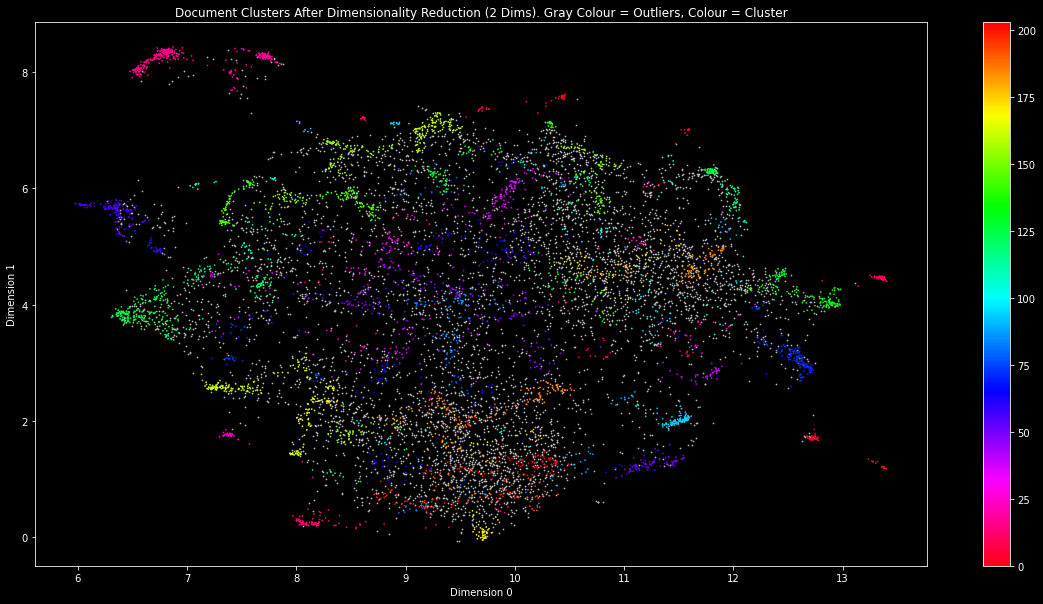

In [43]:
# Prepare data
result = pd.DataFrame(umap_2d, columns=['x', 'y'])
result['labels'] = clusters_umap.labels_
# Visualize clusters
fig, ax = plt.subplots(figsize=(20, 10))
outliers = result.loc[result.labels == -1, :]
clustered = result.loc[result.labels != -1, :]
plt.scatter(outliers.x, outliers.y, color='#BDBDBD', s=0.5)
plt.scatter(clustered.x, clustered.y, c=clustered.labels, s=0.5, cmap='hsv_r')
plt.colorbar()
plt.xlabel("Dimension 0")
plt.ylabel("Dimension 1")
plt.title("Document Clusters After Dimensionality Reduction (2 Dims). Gray Colour = Outliers, Colour = Cluster")


In [26]:
docs_df = pd.DataFrame(texts, columns=["Text"])
docs_df['Topic'] = clusters_umap.labels_
docs_df['Doc_ID'] = range(len(docs_df))
docs_per_topic = docs_df.groupby(['Topic'], as_index = False).agg({'Text': ' '.join})

In [27]:
def c_tf_idf(documents, m, ngram_range=(1, 1)):
    count = CountVectorizer(ngram_range=ngram_range, stop_words="english").fit(documents)
    t = count.transform(documents).toarray()
    w = t.sum(axis=1)
    tf = np.divide(t.T, w)
    sum_t = t.sum(axis=0)
    idf = np.log(np.divide(m, sum_t)).reshape(-1, 1)
    tf_idf = np.multiply(tf, idf)

    return tf_idf, count
  
tf_idf, count = c_tf_idf(docs_per_topic.Text.values, m=len(texts))

In [28]:
def extract_top_n_words_per_topic(tf_idf, count, docs_per_topic, n=20):
    words = count.get_feature_names()
    labels = list(docs_per_topic.Topic)
    tf_idf_transposed = tf_idf.T
    indices = tf_idf_transposed.argsort()[:, -n:]
    top_n_words = {label: [(words[j], tf_idf_transposed[i][j]) for j in indices[i]][::-1] for i, label in enumerate(labels)}
    return top_n_words

def extract_topic_sizes(df):
    topic_sizes = (df.groupby(['Topic'])
                     .Text
                     .count()
                     .reset_index()
                     .rename({"Topic": "Topic", "Text": "Size"}, axis='columns')
                     .sort_values("Size", ascending=False))
    return topic_sizes

top_n_words = extract_top_n_words_per_topic(tf_idf, count, docs_per_topic, n=20)
topic_sizes = extract_topic_sizes(docs_df); 
topic_sizes.head(10)

,Topic,Size
0,-1,5428
17,16,230
124,123,201
57,56,149
72,71,134
19,18,108
95,94,103
162,161,99
161,160,96
132,131,90


In [29]:
topic_sizes.sort_values('Size', ascending=False, inplace=True)

In [31]:
topic_sizes.head(10)

,Topic,Size
0,-1,5428
17,16,230
124,123,201
57,56,149
72,71,134
19,18,108
95,94,103
162,161,99
161,160,96
132,131,90


In [39]:
topic_sizes.shape

(205, 2)

In [32]:
top_n_words[16][:10]

[('dog', 0.07297528827909851),
 ('dogs', 0.027546430393123846),
 ('puppy', 0.015927170089278245),
 ('vet', 0.009762325199251876),
 ('yard', 0.007638119792530594),
 ('walk', 0.0073932563395115595),
 ('leash', 0.0067854621438886336),
 ('care', 0.006382551796905776),
 ('pet', 0.006353882117929895),
 ('barking', 0.005942897230001187)]

In [33]:
top_n_words[123][:10]

[('boss', 0.0250102809280957),
 ('manager', 0.02280398409674557),
 ('job', 0.01825420471044841),
 ('company', 0.015803360005236477),
 ('shift', 0.01407729962011999),
 ('coworker', 0.013671822455804738),
 ('coworkers', 0.01164327530753516),
 ('work', 0.01141160858658858),
 ('employees', 0.010448856642662537),
 ('office', 0.010129666952280826)]

In [34]:
top_n_words[131][:10]

[('pregnant', 0.03819040441918411),
 ('abortion', 0.027534163596562404),
 ('baby', 0.021605365467819906),
 ('pregnancy', 0.020303037358914346),
 ('child', 0.017418392598120388),
 ('kids', 0.01538907177294732),
 ('kid', 0.012541951171665093),
 ('children', 0.010730834037202246),
 ('birth', 0.009216741959325248),
 ('having', 0.00825908663802622)]

In [ ]:
top_n_words[295][:10]

In [35]:
topic_sizes.tail(10)

,Topic,Size
112,111,5
113,112,5
51,50,5
38,37,5
42,41,5
43,42,5
127,126,5
136,135,5
14,13,5
60,59,5


In [36]:
top_n_words[111][:10]

[('motorcycle', 0.13189217784293691),
 ('bike', 0.1089488261806461),
 ('helmet', 0.06222210041045713),
 ('mountain', 0.05131875415081783),
 ('ride', 0.043905697176771376),
 ('bikes', 0.04059937011186307),
 ('bought', 0.03732514243658718),
 ('trail', 0.037317835055550495),
 ('harley', 0.034739734832154485),
 ('rider', 0.03177122442290419)]

In [37]:
top_n_words[59][:10]

[('boyfriend', 0.03232414315597102),
 ('racism', 0.02592494340620517),
 ('pale', 0.023914226354699874),
 ('sister', 0.022744223914656827),
 ('expressed', 0.019661128563728328),
 ('welcoming', 0.015942817569799917),
 ('comments', 0.014909146841924998),
 ('group', 0.014322079705764535),
 ('area', 0.014253832516519028),
 ('visiting', 0.014245103700454287)]

In [38]:
top_n_words[50][:10]

[('gym', 0.0910551233291593),
 ('workout', 0.06476772431631175),
 ('bar', 0.06330356218799665),
 ('wagon', 0.02910006553792516),
 ('weights', 0.027906363992482086),
 ('machine', 0.027632712121434755),
 ('membership', 0.0269804571405559),
 ('meters', 0.026461107999667912),
 ('equipment', 0.021092141024610336),
 ('routine', 0.02096040368720544)]